# 04 — Validation and Insights

**Project:** Transaction Intelligence: Customer Segmentation and Behavioral Analytics  
**Dataset:** Berka / PKDD'99 Financial Dataset  
**Course alignment:**

- **Week 9 — Supervised Learning Techniques**
- **Week 10 — Data-Centric AI and Explainability**
- **Final project synthesis**

This notebook checks the quality and limits of the full project. It includes a small loan-outcome case study to demonstrate supervised learning, reviews the data and earlier clustering results, explains the main outputs, and creates three simple tables for a future dashboard.

The loan case study is **not** the main purpose of the project. It is not a lending system, a credit score, or a fraud model.

## Notebook objectives

1. Build a loan-level dataset using only information available before each loan began.
2. Compare a simple baseline, logistic regression, a Support Vector Machine, and a small decision tree.
3. Evaluate the models with measures that are useful when one outcome is uncommon.
4. Review missing data, coverage, time differences, regional representation, and model errors.
5. Recheck cluster stability and explain segments, PCA, and behavioral outliers in simple terms.
6. Bring the main findings together and create dashboard-ready tables.


## 1. Analytical contract

### Loan case-study question

> Among completed loans, can information known when a loan began help distinguish loans completed with and without repayment problems?

The unit of analysis is one completed loan. The target is:

- `0`: completed without recorded repayment problems;
- `1`: completed with recorded repayment problems.

Active loans are excluded because their final outcome is not yet known in this historical snapshot.

### Safe-use rules

- Results are a course-method demonstration, not a recommendation to approve or reject credit.
- Transactions after the loan date are never used as inputs.
- Loan status, later payments, current segments, and outlier labels are not model inputs.
- Gender, age, and location are not used by the main model. They are kept only for limited quality checks.
- A model error or behavioral outlier is not evidence of fraud, wrongdoing, or poor character.
- The data are historical and cannot describe present-day customers or banking conditions.

### Course content and small extensions

| Part | Role in this notebook |
|---|---|
| Logistic regression, SVM, decision tree, confusion matrix, precision, recall, and F1 | Week 9 course content |
| Data quality, bias, error analysis, reproducibility, and explanations | Week 10 course content |
| Dummy classifier | A simple comparison point: it predicts the most common outcome |
| Leakage audit | A safety check that keeps future information out of the model |
| ROC-AUC and PR-AUC | Extra summary measures; PR-AUC is especially helpful when problem loans are rare |
| Cluster stability, segment profiles, and PCA loadings | Week 8 results checked again here |


## 2. Reproducible setup and required inputs

Notebooks 1–3 produced the clean data, behavior features, segments, and outlier results used here. This notebook reads those files instead of repeating the earlier work.


In [1]:
from pathlib import Path
import hashlib
import platform

import duckdb
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    adjusted_rand_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing pyproject.toml")


def sql_literal(path: Path) -> str:
    return "'" + str(path).replace("'", "''") + "'"


def short_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1_048_576), b""):
            digest.update(chunk)
    return digest.hexdigest()[:12]


PROJECT_ROOT = find_project_root()
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

DATABASE_PATH = INTERIM_DIR / "berka.duckdb"
TRANSACTIONS_PATH = INTERIM_DIR / "transactions_clean.parquet"
LOANS_PATH = INTERIM_DIR / "loans_clean.parquet"
ACCOUNT_BASE_PATH = INTERIM_DIR / "account_analytical_base.parquet"
CUSTOMER_FEATURES_PATH = PROCESSED_DIR / "customer_behavior_features.parquet"
MONTHLY_ACTIVITY_PATH = PROCESSED_DIR / "monthly_banking_activity.parquet"
ASSOCIATION_RULES_PATH = PROCESSED_DIR / "service_association_rules.parquet"
CUSTOMER_SEGMENTS_PATH = PROCESSED_DIR / "customer_segments.parquet"
SEGMENT_PROFILES_PATH = PROCESSED_DIR / "segment_profiles.parquet"
BEHAVIORAL_OUTLIERS_PATH = PROCESSED_DIR / "behavioral_outliers.parquet"

PREPROCESSING_MODEL_PATH = MODELS_DIR / "preprocessing_pipeline.joblib"
PCA_MODEL_PATH = MODELS_DIR / "pca.joblib"
CLUSTERING_MODEL_PATH = MODELS_DIR / "clustering_model.joblib"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 5.5), "axes.titleweight": "bold"})

environment = pd.Series(
    {
        "Python": platform.python_version(),
        "DuckDB": duckdb.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "Random state": RANDOM_STATE,
        "Project root": ".",
    },
    name="value",
)
display(environment.to_frame())


,value
Python,3.11.15
DuckDB,1.5.4
pandas,3.0.3
scikit-learn,1.9.0
Random state,42
Project root,.


In [2]:
required_inputs = {
    "Local DuckDB database": DATABASE_PATH,
    "Clean transactions": TRANSACTIONS_PATH,
    "Clean loans": LOANS_PATH,
    "Account analytical base": ACCOUNT_BASE_PATH,
    "Customer behavior features": CUSTOMER_FEATURES_PATH,
    "Monthly banking activity": MONTHLY_ACTIVITY_PATH,
    "Service association rules": ASSOCIATION_RULES_PATH,
    "Customer segments": CUSTOMER_SEGMENTS_PATH,
    "Segment profiles": SEGMENT_PROFILES_PATH,
    "Behavioral outliers": BEHAVIORAL_OUTLIERS_PATH,
    "Segmentation preprocessor": PREPROCESSING_MODEL_PATH,
    "PCA model": PCA_MODEL_PATH,
    "Clustering model": CLUSTERING_MODEL_PATH,
}

input_status = pd.DataFrame(
    [
        {
            "input": name,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.is_file(),
            "size_mb": round(path.stat().st_size / 1_048_576, 3) if path.is_file() else None,
        }
        for name, path in required_inputs.items()
    ]
)
display(input_status)
assert input_status["exists"].all(), "Run Notebooks 1–3 before this notebook."

connection = duckdb.connect(str(DATABASE_PATH), read_only=True)

transactions_scan = "read_parquet(" + sql_literal(TRANSACTIONS_PATH) + ")"
loans_scan = "read_parquet(" + sql_literal(LOANS_PATH) + ")"
account_base_scan = "read_parquet(" + sql_literal(ACCOUNT_BASE_PATH) + ")"

customer_features = connection.execute(
    "SELECT * FROM read_parquet(" + sql_literal(CUSTOMER_FEATURES_PATH) + ") ORDER BY account_id"
).fetchdf()
monthly_activity = connection.execute(
    "SELECT * FROM read_parquet(" + sql_literal(MONTHLY_ACTIVITY_PATH) + ") ORDER BY month"
).fetchdf()
association_rules_data = connection.execute(
    "SELECT * FROM read_parquet(" + sql_literal(ASSOCIATION_RULES_PATH) + ")"
).fetchdf()
customer_segments = connection.execute(
    "SELECT * FROM read_parquet(" + sql_literal(CUSTOMER_SEGMENTS_PATH) + ") ORDER BY account_id"
).fetchdf()
segment_profiles = connection.execute(
    "SELECT * FROM read_parquet(" + sql_literal(SEGMENT_PROFILES_PATH) + ") ORDER BY segment_id"
).fetchdf()
behavioral_outliers = connection.execute(
    "SELECT * FROM read_parquet(" + sql_literal(BEHAVIORAL_OUTLIERS_PATH) + ") ORDER BY account_id"
).fetchdf()

assert len(customer_features) == customer_features["account_id"].nunique()
assert len(customer_segments) == customer_segments["account_id"].nunique()
assert len(segment_profiles) == customer_segments["segment_id"].nunique()
assert len(behavioral_outliers) == behavioral_outliers["account_id"].nunique()

input_versions = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(PROJECT_ROOT)),
            "sha256_first_12": short_sha256(path),
        }
        for path in required_inputs.values()
    ]
)
display(input_versions)


,input,path,exists,size_mb
0,Local DuckDB database,data/interim/berka.duckdb,True,46.262
1,Clean transactions,data/interim/transactions_clean.parquet,True,7.636
2,Clean loans,data/interim/loans_clean.parquet,True,0.010
3,Account analytical base,data/interim/account_analytical_base.parquet,True,0.121
4,Customer behavior features,data/processed/customer_behavior_features.parquet,True,0.369
5,Monthly banking activity,data/processed/monthly_banking_activity.parquet,True,0.006
6,Service association rules,data/processed/service_association_rules.parquet,True,0.003
7,Customer segments,data/processed/customer_segments.parquet,True,0.079
8,Segment profiles,data/processed/segment_profiles.parquet,True,0.009
9,Behavioral outliers,data/processed/behavioral_outliers.parquet,True,0.216


,path,sha256_first_12
0,data/interim/berka.duckdb,d9bcd69bec26
1,data/interim/transactions_clean.parquet,6b048b8490e8
2,data/interim/loans_clean.parquet,df9976d89f3f
3,data/interim/account_analytical_base.parquet,e14a6089ae0f
4,data/processed/customer_behavior_features.parquet,18b345e96735
5,data/processed/monthly_banking_activity.parquet,7e44e210bbb9
6,data/processed/service_association_rules.parquet,0170efb3be5f
7,data/processed/customer_segments.parquet,37531ec9e8b8
8,data/processed/segment_profiles.parquet,38c9ff087b25
9,data/processed/behavioral_outliers.parquet,c00b8ad12cee


## 3. Week 9 — Supervised Learning Techniques

### Build the completed-loan study table

Every transaction feature below is calculated with this rule:

```text
transaction date < loan start date
```

This is the **feature-availability cutoff**. In plain language, the model may only use facts that would already have been known when the loan began.


In [3]:
LOAN_MODEL_SQL = """
WITH completed_loans AS (
    SELECT *
    FROM {loans}
    WHERE is_completed
),
preloan_transactions AS (
    SELECT
        l.loan_id,
        COUNT(t.trans_id) AS preloan_transaction_count,
        COUNT(DISTINCT DATE_TRUNC('month', t.transaction_date)) AS preloan_active_months,
        MAX(t.transaction_date) AS latest_preloan_transaction_date,
        AVG(t.amount) FILTER (WHERE t.transaction_direction = 'inflow')
            AS preloan_average_inflow,
        AVG(t.amount) FILTER (WHERE t.transaction_direction = 'outflow')
            AS preloan_average_outflow,
        SUM(t.amount) FILTER (WHERE t.transaction_direction = 'inflow')
            AS preloan_total_inflow,
        SUM(t.amount) FILTER (WHERE t.transaction_direction = 'outflow')
            AS preloan_total_outflow,
        AVG(t.balance) AS preloan_average_balance,
        STDDEV_POP(t.balance) AS preloan_balance_std,
        MIN(t.balance) AS preloan_minimum_balance,
        AVG(CAST(t.balance < 0 AS INTEGER)) AS preloan_negative_balance_share,
        COUNT(DISTINCT COALESCE(t.operation, 'missing')) AS preloan_operation_diversity,
        AVG(CAST(t.operation = 'incoming_transfer' AS INTEGER))
            AS preloan_incoming_transfer_share
    FROM completed_loans AS l
    JOIN {transactions} AS t
      ON l.account_id = t.account_id
     AND t.transaction_date < l.loan_date
    GROUP BY l.loan_id
)
SELECT
    l.loan_id,
    l.account_id,
    l.loan_date,
    EXTRACT(YEAR FROM l.loan_date)::INTEGER AS loan_year,
    l.loan_amount,
    l.duration_months,
    CAST(l.monthly_payment AS DOUBLE) AS monthly_payment,
    CAST(l.completed_repayment_problem AS INTEGER) AS repayment_problem,
    b.account_open_date,
    b.statement_frequency,
    b.account_region,
    b.account_district_id,
    b.owner_gender,
    DATE_DIFF('year', b.owner_birth_date, l.loan_date) AS owner_age_at_loan,
    GREATEST(DATE_DIFF('month', b.account_open_date, l.loan_date) + 1, 1)
        AS account_age_months_at_loan,
    CAST(b.first_card_issued IS NOT NULL AND b.first_card_issued <= l.loan_date AS INTEGER)
        AS has_card_before_loan,
    p.latest_preloan_transaction_date,
    p.preloan_transaction_count,
    p.preloan_active_months,
    p.preloan_transaction_count
        / GREATEST(DATE_DIFF('month', b.account_open_date, l.loan_date) + 1, 1)::DOUBLE
        AS preloan_transactions_per_month,
    p.preloan_active_months
        / GREATEST(DATE_DIFF('month', b.account_open_date, l.loan_date) + 1, 1)::DOUBLE
        AS preloan_active_month_ratio,
    p.preloan_average_inflow,
    p.preloan_average_outflow,
    p.preloan_total_inflow / NULLIF(p.preloan_total_outflow, 0)
        AS preloan_inflow_to_outflow_ratio,
    p.preloan_average_balance,
    p.preloan_balance_std,
    p.preloan_minimum_balance,
    p.preloan_negative_balance_share,
    p.preloan_operation_diversity,
    p.preloan_incoming_transfer_share,
    CAST(l.monthly_payment AS DOUBLE) / NULLIF(p.preloan_average_inflow, 0)
        AS payment_to_average_inflow_ratio
FROM completed_loans AS l
JOIN {account_base} AS b USING (account_id)
JOIN preloan_transactions AS p USING (loan_id)
ORDER BY l.loan_date, l.loan_id
""".format(
    loans=loans_scan,
    transactions=transactions_scan,
    account_base=account_base_scan,
)

loan_model_data = connection.execute(LOAN_MODEL_SQL).fetchdf()

loan_cohort_check = pd.Series(
    {
        "Completed loans": len(loan_model_data),
        "Unique loan IDs": loan_model_data["loan_id"].nunique(),
        "Loans with a recorded problem": loan_model_data["repayment_problem"].sum(),
        "Loans without a recorded problem": (loan_model_data["repayment_problem"] == 0).sum(),
        "Missing targets": loan_model_data["repayment_problem"].isna().sum(),
        "Latest allowed transaction is before loan date": bool(
            (loan_model_data["latest_preloan_transaction_date"] < loan_model_data["loan_date"]).all()
        ),
    },
    name="value",
)
display(loan_cohort_check.to_frame())

assert len(loan_model_data) == loan_model_data["loan_id"].nunique()
assert loan_model_data["repayment_problem"].notna().all()
assert (loan_model_data["latest_preloan_transaction_date"] < loan_model_data["loan_date"]).all()


,value
Completed loans,234
Unique loan IDs,234
Loans with a recorded problem,31
Loans without a recorded problem,203
Missing targets,0
Latest allowed transaction is before loan date,True


### Target balance

The two outcomes do not occur equally often. A model could look accurate by predicting the common outcome every time, while finding no problem loans at all. This is why the notebook reports precision, recall, F1, ROC-AUC, and PR-AUC instead of relying only on accuracy.


,outcome,loans,share_pct
0,Completed without problems,203,86.752137
1,Completed with problems,31,13.247863


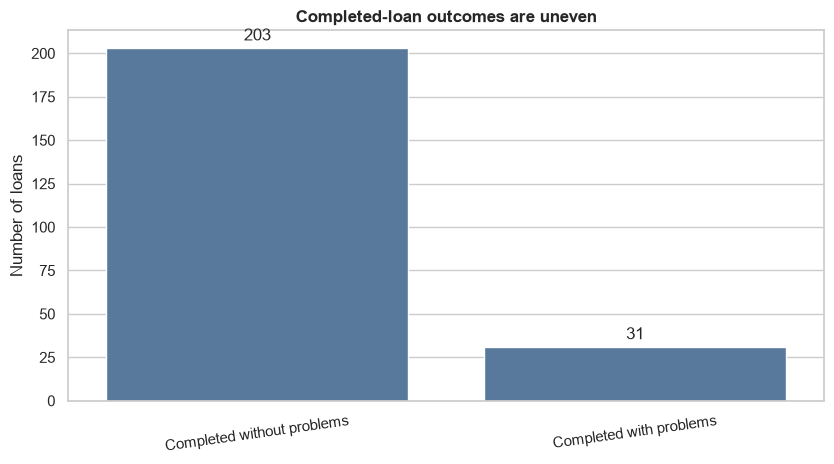

In [4]:
target_distribution = (
    loan_model_data["repayment_problem"]
    .map({0: "Completed without problems", 1: "Completed with problems"})
    .value_counts()
    .rename_axis("outcome")
    .reset_index(name="loans")
)
target_distribution["share_pct"] = 100 * target_distribution["loans"] / len(loan_model_data)
display(target_distribution)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.barplot(data=target_distribution, x="outcome", y="loans", color="#4C78A8", ax=ax)
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.set(title="Completed-loan outcomes are uneven", xlabel="", ylabel="Number of loans")
ax.tick_params(axis="x", rotation=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "loan_target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


### Leakage audit and feature choices

**Data leakage** means giving the model information that would not have been available at the time of the decision. That can make results look much better than they really are.

| Information | Use | Reason |
|---|---|---|
| Loan amount and planned duration | Model input | Known when the loan begins |
| Transactions before the loan date | Model input | Available history only |
| Statement frequency | Model input | Existing account setting |
| Loan status or later loan payments | Excluded | These reveal or follow the outcome |
| Transactions on or after the loan date | Excluded | Future information |
| Full-history customer features from Notebook 2 | Excluded | They include activity after many loan dates |
| Segment and outlier labels | Excluded | They use the full historical observation window |
| Standing orders | Excluded | The source table has no start date, so availability cannot be proven |
| Gender, age, district, and region | Audit only | Not needed for the main prediction and sensitive to misuse |
| Card indicator | Sensitivity check only | Few completed-loan accounts had a card before the loan |

The primary model uses a compact set of loan terms and earlier account behavior. Monthly payment is not used by itself because it is already determined by loan amount and duration. It is used only in a ratio that compares the planned payment with earlier average inflow.


In [5]:
LOAN_TERM_FEATURES = [
    "loan_amount",
    "duration_months",
]

PRELOAN_BEHAVIOR_FEATURES = [
    "account_age_months_at_loan",
    "preloan_transactions_per_month",
    "preloan_active_month_ratio",
    "preloan_average_inflow",
    "preloan_average_outflow",
    "preloan_inflow_to_outflow_ratio",
    "preloan_average_balance",
    "preloan_negative_balance_share",
    "preloan_operation_diversity",
    "preloan_incoming_transfer_share",
    "payment_to_average_inflow_ratio",
]

PRIMARY_NUMERIC_FEATURES = LOAN_TERM_FEATURES + PRELOAN_BEHAVIOR_FEATURES
PRIMARY_CATEGORICAL_FEATURES = ["statement_frequency"]
PRIMARY_FEATURES = PRIMARY_NUMERIC_FEATURES + PRIMARY_CATEGORICAL_FEATURES
TARGET = "repayment_problem"

feature_guide = pd.DataFrame(
    [
        ("Loan terms", "Loan amount and planned duration", "Known at the start"),
        ("Account history", "Months since the account opened", "Shows how much history exists"),
        ("Activity", "Transactions and active months", "Describes earlier account use"),
        ("Cash flow", "Average inflow, outflow, and their ratio", "Describes money moving in and out"),
        ("Balance", "Average balance and share of negative balances", "Describes earlier balance condition"),
        ("Channel mix", "Operation variety and incoming-transfer share", "Describes how the account was used"),
        ("Payment pressure", "Planned payment divided by earlier average inflow", "Compares the payment with earlier inflow"),
        ("Account setting", "Statement frequency", "A simple existing service setting"),
    ],
    columns=["group", "included information", "plain-language purpose"],
)
display(feature_guide)


,group,included information,plain-language purpose
0,Loan terms,Loan amount and planned duration,Known at the start
1,Account history,Months since the account opened,Shows how much history exists
2,Activity,Transactions and active months,Describes earlier account use
3,Cash flow,"Average inflow, outflow, and their ratio",Describes money moving in and out
4,Balance,Average balance and share of negative balances,Describes earlier balance condition
5,Channel mix,Operation variety and incoming-transfer share,Describes how the account was used
6,Payment pressure,Planned payment divided by earlier average inflow,Compares the payment with earlier inflow
7,Account setting,Statement frequency,A simple existing service setting


### Train/test split and preparation

The data are split once into:

- **70% training data:** used to fit the models;
- **30% test data:** kept aside until evaluation.

The split keeps roughly the same outcome share in both parts. This is called a **stratified split**. A random split is used because the completed-loan sample is small. The result measures performance on held-out loans from this historical sample; it does not prove performance on future loans.

Numeric values are filled with the training median when needed and then placed on a comparable scale. Statement frequency is converted into indicator columns. All preparation steps are fitted on the training data only.


In [6]:
X = loan_model_data[PRIMARY_FEATURES].copy()
y = loan_model_data[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame(
    [
        {
            "split": "Training",
            "loans": len(y_train),
            "problem_loans": int(y_train.sum()),
            "problem_rate_pct": 100 * y_train.mean(),
        },
        {
            "split": "Test",
            "loans": len(y_test),
            "problem_loans": int(y_test.sum()),
            "problem_rate_pct": 100 * y_test.mean(),
        },
    ]
)
display(split_summary.round(2))


def make_preprocessor(numeric_features, categorical_features):
    steps = []
    if numeric_features:
        steps.append(
            (
                "numeric",
                Pipeline(
                    steps=[
                        ("fill_missing", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler()),
                    ]
                ),
                numeric_features,
            )
        )
    if categorical_features:
        steps.append(
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_features,
            )
        )
    return ColumnTransformer(steps)


primary_preprocessor = make_preprocessor(
    PRIMARY_NUMERIC_FEATURES,
    PRIMARY_CATEGORICAL_FEATURES,
)


,split,loans,problem_loans,problem_rate_pct
0,Training,163,22,13.50
1,Test,71,9,12.68


### Model comparison

| Model | Simple description |
|---|---|
| Dummy classifier | Always follows the most common training outcome; it is the minimum comparison point |
| Logistic regression | Learns a weighted combination of the inputs and is easy to explain |
| Support Vector Machine (SVM) | Finds a flexible boundary between the two outcomes |
| Shallow decision tree | Uses a small set of yes/no splits; depth is limited to reduce overfitting |

The three fitted models use balanced class weights. This asks them to pay more attention to the uncommon problem-loan class. It does not create new observations.


In [7]:
model_definitions = {
    "Dummy baseline": DummyClassifier(strategy="prior"),
    "Logistic regression": LogisticRegression(
        max_iter=2_000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Support Vector Machine": SVC(
        kernel="rbf",
        class_weight="balanced",
    ),
    "Shallow decision tree": DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

fitted_models = {}
prediction_store = {}
evaluation_rows = []

for model_name, estimator in model_definitions.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessing", clone(primary_preprocessor)),
            ("model", estimator),
        ]
    )
    pipeline.fit(X_train, y_train)
    predicted = pipeline.predict(X_test)
    if hasattr(pipeline, "predict_proba"):
        score = pipeline.predict_proba(X_test)[:, 1]
    else:
        score = pipeline.decision_function(X_test)

    fitted_models[model_name] = pipeline
    prediction_store[model_name] = {"predicted": predicted, "score": score}
    evaluation_rows.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, predicted),
            "precision": precision_score(y_test, predicted, zero_division=0),
            "recall": recall_score(y_test, predicted, zero_division=0),
            "f1": f1_score(y_test, predicted, zero_division=0),
            "roc_auc": roc_auc_score(y_test, score),
            "pr_auc": average_precision_score(y_test, score),
            "predicted_problem_loans": int(predicted.sum()),
        }
    )

model_evaluation = pd.DataFrame(evaluation_rows)
display(model_evaluation.round(3))


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,predicted_problem_loans
0,Dummy baseline,0.873,0.000,0.000,0.000,0.500,0.127,0
1,Logistic regression,0.859,0.462,0.667,0.545,0.892,0.471,13
2,Support Vector Machine,0.873,0.500,0.556,0.526,0.738,0.440,10
3,Shallow decision tree,0.690,0.259,0.778,0.389,0.723,0.245,27


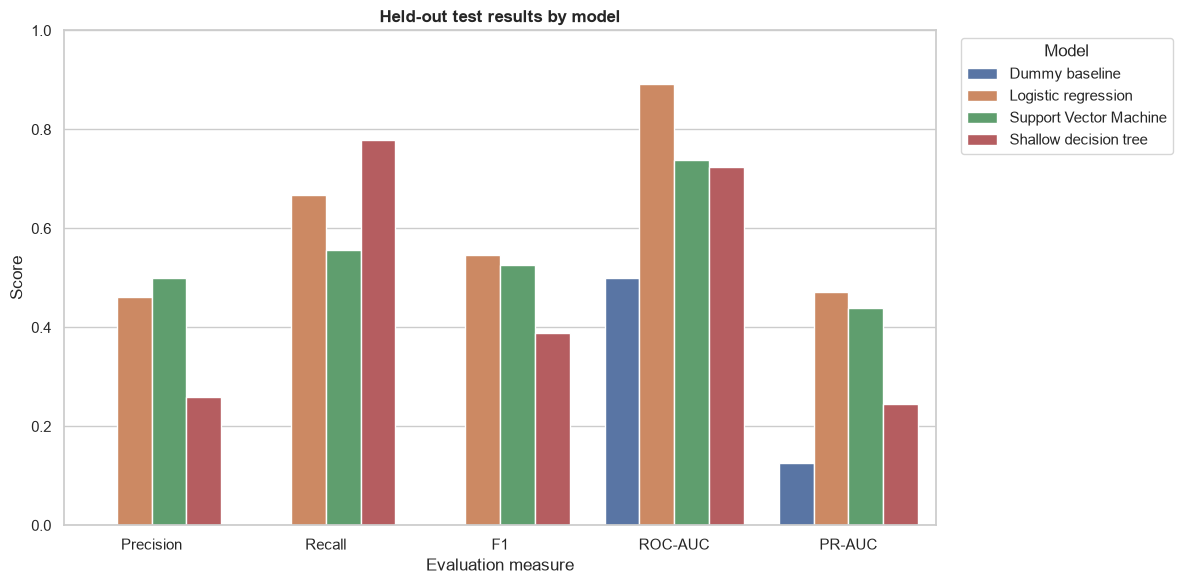

In [8]:
metric_columns = ["precision", "recall", "f1", "roc_auc", "pr_auc"]
model_plot_data = model_evaluation.melt(
    id_vars="model",
    value_vars=metric_columns,
    var_name="measure",
    value_name="score",
)
model_plot_data["measure"] = model_plot_data["measure"].map(
    {
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1",
        "roc_auc": "ROC-AUC",
        "pr_auc": "PR-AUC",
    }
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=model_plot_data, x="measure", y="score", hue="model", ax=ax)
ax.set(
    title="Held-out test results by model",
    xlabel="Evaluation measure",
    ylabel="Score",
    ylim=(0, 1),
)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "loan_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


### How to read the measures

- **Precision:** when the model flags a problem, how often is it correct?
- **Recall:** of the recorded problem loans, how many does the model find?
- **F1:** one score that balances precision and recall.
- **ROC-AUC:** how well the model generally ranks problem loans above non-problem loans across many cutoffs.
- **PR-AUC:** how well precision and recall work together across many cutoffs. It is useful here because problem loans are uncommon.

Logistic regression is kept as the main case-study model because it gives the best overall balance in this fixed comparison and its coefficients can be explained directly. The test set contains very few problem loans, so small changes in predictions can move these scores substantially.


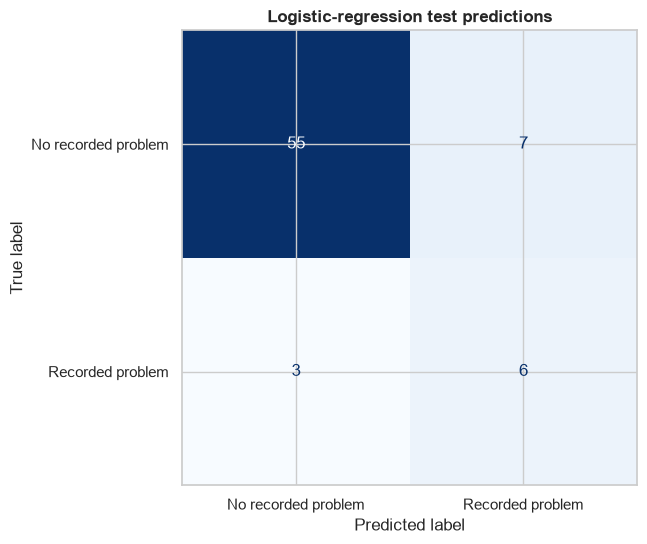

,loans
Correct non-problem predictions,55
False alarms,7
Missed problem loans,3
Correct problem predictions,6


In [9]:
SELECTED_LOAN_MODEL = "Logistic regression"
selected_predictions = prediction_store[SELECTED_LOAN_MODEL]["predicted"]
selected_scores = prediction_store[SELECTED_LOAN_MODEL]["score"]

fig, ax = plt.subplots(figsize=(6.8, 5.6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    selected_predictions,
    display_labels=["No recorded problem", "Recorded problem"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Logistic-regression test predictions")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "loan_logistic_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, selected_predictions).ravel()
confusion_summary = pd.Series(
    {
        "Correct non-problem predictions": tn,
        "False alarms": fp,
        "Missed problem loans": fn,
        "Correct problem predictions": tp,
    },
    name="loans",
)
display(confusion_summary.to_frame())


### Error review

A confusion matrix counts correct and incorrect predictions. The next table looks at the actual test cases behind those counts. This can show where the model struggles, but it cannot prove why a repayment problem happened.


In [10]:
test_results = loan_model_data.loc[X_test.index].copy()
test_results["actual_problem"] = y_test
test_results["predicted_problem"] = selected_predictions
test_results["model_score"] = selected_scores
test_results["result_type"] = np.select(
    [
        (test_results["actual_problem"] == 0) & (test_results["predicted_problem"] == 0),
        (test_results["actual_problem"] == 0) & (test_results["predicted_problem"] == 1),
        (test_results["actual_problem"] == 1) & (test_results["predicted_problem"] == 0),
        (test_results["actual_problem"] == 1) & (test_results["predicted_problem"] == 1),
    ],
    ["correct non-problem", "false alarm", "missed problem", "correct problem"],
    default="unknown",
)

error_counts = test_results["result_type"].value_counts().rename_axis("result_type").reset_index(name="loans")
display(error_counts)

error_feature_summary = (
    test_results.groupby("result_type")
    .agg(
        loans=("loan_id", "size"),
        median_loan_amount=("loan_amount", "median"),
        median_payment_to_inflow=("payment_to_average_inflow_ratio", "median"),
        median_preloan_balance=("preloan_average_balance", "median"),
        median_preloan_transactions_per_month=("preloan_transactions_per_month", "median"),
    )
    .reset_index()
)
display(error_feature_summary.round(2))

error_case_view = test_results.loc[
        test_results["actual_problem"] != test_results["predicted_problem"],
        [
            "loan_id",
            "loan_date",
            "actual_problem",
            "predicted_problem",
            "model_score",
            "loan_amount",
            "payment_to_average_inflow_ratio",
            "preloan_average_balance",
            "account_region",
        ],
    ].sort_values("model_score", ascending=False)
numeric_error_columns = [
    "model_score",
    "loan_amount",
    "payment_to_average_inflow_ratio",
    "preloan_average_balance",
]
error_case_view[numeric_error_columns] = error_case_view[numeric_error_columns].round(3)
display(error_case_view)


,result_type,loans
0,correct non-problem,55
1,false alarm,7
2,correct problem,6
3,missed problem,3


,result_type,loans,median_loan_amount,median_payment_to_inflow,median_preloan_balance,median_preloan_transactions_per_month
0,correct non-problem,55,74040.0,0.31,42291.30,5.36
1,correct problem,6,140268.0,0.46,34536.50,3.43
2,false alarm,7,134784.0,0.64,44131.23,5.25
3,missed problem,3,75624.0,0.27,50010.00,3.29


,loan_id,loan_date,actual_problem,predicted_problem,model_score,loan_amount,payment_to_average_inflow_ratio,preloan_average_balance,account_region
9,5997,1993-11-04,0,1,0.824,117024,0.371,44131.231,south Bohemia
69,6841,1994-08-07,0,1,0.669,172080,0.335,60744.119,central Bohemia
117,6694,1995-03-19,0,1,0.638,134784,0.637,44005.164,north Moravia
156,6589,1996-01-01,0,1,0.636,189696,0.424,54136.966,south Bohemia
105,5739,1995-01-02,0,1,0.635,76380,1.385,26122.733,Prague
179,5375,1996-10-03,0,1,0.635,101520,1.379,26449.289,Prague
88,6808,1994-10-12,0,1,0.530,227880,0.780,45134.783,south Moravia
65,5395,1994-07-30,1,0,0.468,299088,0.470,51992.944,north Moravia
19,7097,1993-12-23,1,0,0.461,75624,0.270,50010.000,south Moravia
159,6027,1996-02-10,1,0,0.426,61656,0.184,44763.500,central Bohemia


### Logistic-regression explanation

A positive coefficient moves the model toward the “recorded problem” outcome. A negative coefficient moves it away. Larger absolute values have more influence **inside this fitted model**.

Coefficients show model associations after scaling; they do not show cause. Correlated inputs can also share or move influence between them.


,feature,coefficient,absolute_coefficient
9,preloan_negative_balance_share,1.861,1.861
10,preloan_operation_diversity,-1.481,1.481
8,preloan_average_balance,-0.956,0.956
3,preloan_transactions_per_month,0.871,0.871
6,preloan_average_outflow,0.603,0.603
12,payment_to_average_inflow_ratio,0.595,0.595
11,preloan_incoming_transfer_share,0.572,0.572
2,account_age_months_at_loan,-0.541,0.541
5,preloan_average_inflow,0.493,0.493
4,preloan_active_month_ratio,-0.403,0.403


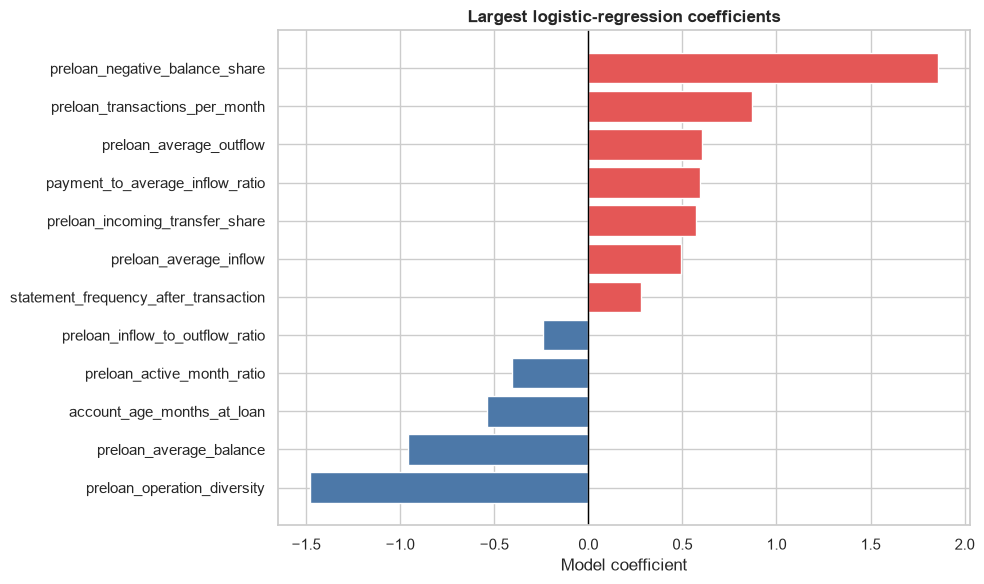

In [11]:
logistic_pipeline = fitted_models[SELECTED_LOAN_MODEL]
transformed_feature_names = logistic_pipeline.named_steps["preprocessing"].get_feature_names_out()
coefficient_values = logistic_pipeline.named_steps["model"].coef_[0]

coefficient_table = pd.DataFrame(
    {
        "feature": transformed_feature_names,
        "coefficient": coefficient_values,
        "absolute_coefficient": np.abs(coefficient_values),
    }
).sort_values("absolute_coefficient", ascending=False)
coefficient_table["feature"] = (
    coefficient_table["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)
display(coefficient_table.head(12).round(3))

top_coefficients = coefficient_table.head(12).sort_values("coefficient")
fig, ax = plt.subplots(figsize=(10, 6))
colors = np.where(top_coefficients["coefficient"] >= 0, "#E45756", "#4C78A8")
ax.barh(top_coefficients["feature"], top_coefficients["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set(title="Largest logistic-regression coefficients", xlabel="Model coefficient", ylabel="")
fig.tight_layout()
plt.show()


**Why SHAP is not added:** logistic-regression coefficients already give a clear explanation for this small demonstration. Adding another explanation tool would make the notebook longer without changing the main conclusion. SHAP would be useful later if a more complex final model needed individual explanations.


## 4. Week 10 — Data-Centric AI and Explainability

Data-centric AI asks whether the data are suitable, complete enough, representative enough, and reproducible. Better modelling cannot repair a poorly defined target or missing historical coverage.


### Data quality before and after preparation

“Before” refers to the source-style `loan` table in the local DuckDB snapshot. “After” refers to the cleaned loan table from Notebook 1 and the completed-loan study table built above.


In [12]:
raw_loan_quality = connection.execute(
    """
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT loan_id) AS unique_loan_ids,
        COUNT(*) FILTER (
            WHERE loan_id IS NULL OR account_id IS NULL OR date IS NULL
               OR amount IS NULL OR duration IS NULL OR payments IS NULL OR status IS NULL
        ) AS rows_missing_required_values,
        COUNT(*) FILTER (WHERE status IN ('A', 'B', 'C', 'D')) AS recognized_status_codes
    FROM loan
    """
).fetchdf().iloc[0]

clean_loan_quality = connection.execute(
    """
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT loan_id) AS unique_loan_ids,
        COUNT(*) FILTER (
            WHERE loan_id IS NULL OR account_id IS NULL OR loan_date IS NULL
               OR loan_amount IS NULL OR duration_months IS NULL
               OR monthly_payment IS NULL OR loan_status IS NULL
        ) AS rows_missing_required_values,
        COUNT(*) FILTER (WHERE loan_status IS NOT NULL) AS readable_status_labels,
        COUNT(*) FILTER (WHERE is_completed AND completed_repayment_problem IS NOT NULL)
            AS completed_targets_available
    FROM read_parquet(""" + sql_literal(LOANS_PATH) + ")"
).fetchdf().iloc[0]

data_quality_comparison = pd.DataFrame(
    [
        {
            "check": "Rows retained",
            "source": int(raw_loan_quality["rows"]),
            "prepared": int(clean_loan_quality["rows"]),
            "meaning": "Cleaning did not silently remove loans",
        },
        {
            "check": "Unique loan IDs",
            "source": int(raw_loan_quality["unique_loan_ids"]),
            "prepared": int(clean_loan_quality["unique_loan_ids"]),
            "meaning": "One ID still identifies one loan",
        },
        {
            "check": "Rows missing required values",
            "source": int(raw_loan_quality["rows_missing_required_values"]),
            "prepared": int(clean_loan_quality["rows_missing_required_values"]),
            "meaning": "Core loan fields are complete",
        },
        {
            "check": "Recognized or readable statuses",
            "source": int(raw_loan_quality["recognized_status_codes"]),
            "prepared": int(clean_loan_quality["readable_status_labels"]),
            "meaning": "All four source codes have clear labels",
        },
        {
            "check": "Completed targets available",
            "source": "Not present",
            "prepared": int(clean_loan_quality["completed_targets_available"]),
            "meaning": "The target is defined only for completed loans",
        },
    ]
)
display(data_quality_comparison)


,check,source,prepared,meaning
0,Rows retained,682,682,Cleaning did not silently remove loans
1,Unique loan IDs,682,682,One ID still identifies one loan
2,Rows missing required values,0,0,Core loan fields are complete
3,Recognized or readable statuses,682,682,All four source codes have clear labels
4,Completed targets available,Not present,234,The target is defined only for completed loans


### Missing values and coverage gaps

Missing values are not all the same. Here, two completed-loan accounts had no earlier outflow, so their earlier average outflow and inflow-to-outflow ratio are missing. The model fills these numeric values with the training median. No target is filled or guessed.

Coverage is a larger concern than those two missing values: only a small share of all accounts has a completed loan, and recorded problem loans are rarer still.


In [13]:
feature_missingness = (
    loan_model_data[PRIMARY_FEATURES]
    .isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)
feature_missingness["missing_share_pct"] = 100 * feature_missingness["missing_values"] / len(loan_model_data)
display(feature_missingness.query("missing_values > 0").round(2))

portfolio_counts = connection.execute(
    "SELECT COUNT(*) AS accounts FROM " + account_base_scan
).fetchdf().iloc[0]
loan_counts = connection.execute(
    """
    SELECT
        COUNT(*) AS all_loans,
        COUNT(DISTINCT account_id) AS accounts_with_loans,
        COUNT(*) FILTER (WHERE is_completed) AS completed_loans,
        COUNT(*) FILTER (WHERE completed_repayment_problem) AS completed_problem_loans
    FROM read_parquet(""" + sql_literal(LOANS_PATH) + ")"
).fetchdf().iloc[0]

coverage_table = pd.DataFrame(
    [
        ("All accounts", int(portfolio_counts["accounts"]), "Full account-level project coverage"),
        ("Accounts with any loan", int(loan_counts["accounts_with_loans"]), "Only these accounts appear in the loan table"),
        ("Completed loans", int(loan_counts["completed_loans"]), "Only these have a final outcome for this target"),
        ("Completed loans with recorded problems", int(loan_counts["completed_problem_loans"]), "Uncommon positive class"),
    ],
    columns=["group", "count", "meaning"],
)
coverage_table["share_of_all_accounts_pct"] = 100 * coverage_table["count"] / int(portfolio_counts["accounts"])
display(coverage_table.round(2))


,missing_values,missing_share_pct
preloan_average_outflow,2,0.85
preloan_inflow_to_outflow_ratio,2,0.85


,group,count,meaning,share_of_all_accounts_pct
0,All accounts,4500,Full account-level project coverage,100.00
1,Accounts with any loan,682,Only these accounts appear in the loan table,15.16
2,Completed loans,234,Only these have a final outcome for this target,5.20
3,Completed loans with recorded problems,31,Uncommon positive class,0.69


### Historical and time differences

The data cover a short period in the 1990s. The number of completed loans and the recorded problem rate change by year. These differences may reflect changing customers, changing bank processes, or simple variation from small yearly counts.


,loan_year,completed_loans,problem_loans,problem_rate
0,1993,20,4,0.200
1,1994,85,12,0.141
2,1995,51,6,0.118
3,1996,35,6,0.171
4,1997,43,3,0.070


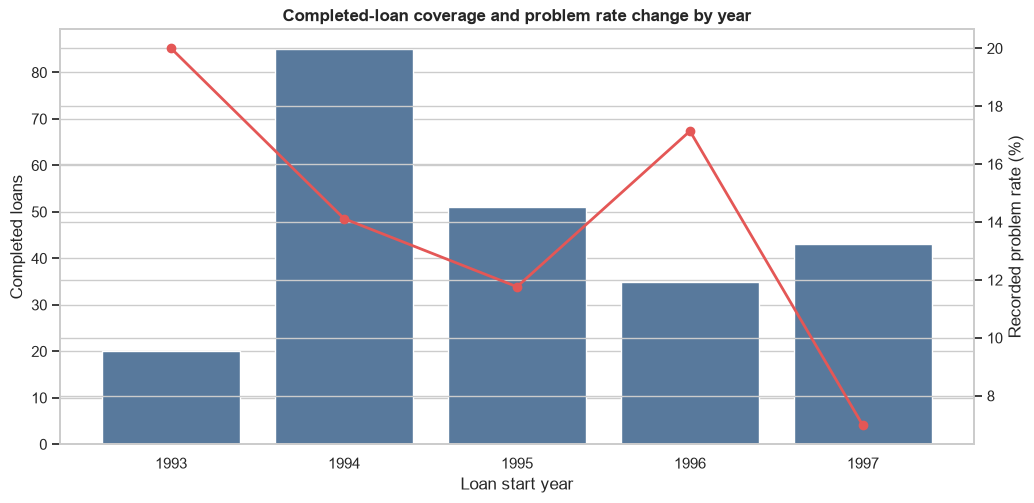

In [14]:
loan_year_summary = (
    loan_model_data.groupby("loan_year")
    .agg(
        completed_loans=("loan_id", "size"),
        problem_loans=("repayment_problem", "sum"),
        problem_rate=("repayment_problem", "mean"),
    )
    .reset_index()
)
display(loan_year_summary.round(3))

fig, ax_count = plt.subplots(figsize=(10.5, 5.2))
sns.barplot(data=loan_year_summary, x="loan_year", y="completed_loans", color="#4C78A8", ax=ax_count)
ax_count.set(xlabel="Loan start year", ylabel="Completed loans", title="Completed-loan coverage and problem rate change by year")

ax_rate = ax_count.twinx()
ax_rate.plot(
    range(len(loan_year_summary)),
    100 * loan_year_summary["problem_rate"],
    color="#E45756",
    marker="o",
    linewidth=2,
)
ax_rate.set_ylabel("Recorded problem rate (%)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "loan_outcomes_by_year.png", dpi=160, bbox_inches="tight")
plt.show()


### Regional representation and error checks

Districts are too small for reliable district-by-district model conclusions, so the audit uses the eight broader regions. The table shows coverage and test errors. A high or low rate in a small group is a warning to investigate, not proof of bias or fairness.


In [15]:
region_coverage = (
    loan_model_data.groupby("account_region")
    .agg(
        completed_loans=("loan_id", "size"),
        problem_loans=("repayment_problem", "sum"),
        problem_rate=("repayment_problem", "mean"),
        represented_districts=("account_district_id", "nunique"),
    )
    .reset_index()
)

region_test_errors = (
    test_results.assign(is_error=test_results["actual_problem"] != test_results["predicted_problem"])
    .groupby("account_region")
    .agg(
        test_loans=("loan_id", "size"),
        test_errors=("is_error", "sum"),
        test_error_rate=("is_error", "mean"),
    )
    .reset_index()
)

region_audit = region_coverage.merge(region_test_errors, on="account_region", how="left")
display(region_audit.sort_values("completed_loans", ascending=False).round(3))


,account_region,completed_loans,problem_loans,problem_rate,represented_districts,test_loans,test_errors,test_error_rate
4,north Moravia,41,6,0.146,10,11,2,0.182
6,south Moravia,41,6,0.146,13,11,2,0.182
0,Prague,37,3,0.081,1,19,2,0.105
1,central Bohemia,31,5,0.161,11,8,2,0.250
5,south Bohemia,23,5,0.217,8,5,2,0.400
7,west Bohemia,22,5,0.227,8,9,0,0.000
3,north Bohemia,20,1,0.050,8,2,0,0.000
2,east Bohemia,19,0,0.000,11,6,0,0.000


### Feature sensitivity

A sensitivity check asks whether the conclusion changes when the input set changes. The same logistic-regression method and the same train/test rows are used three times:

1. loan terms only;
2. loan terms plus earlier account behavior;
3. the same inputs plus region and the rare pre-loan card indicator.

This is not a search for the highest possible score. It checks whether extra information adds clear value.


In [16]:
feature_variants = {
    "Loan terms only": (LOAN_TERM_FEATURES, []),
    "Terms + pre-loan behavior": (
        LOAN_TERM_FEATURES + PRELOAN_BEHAVIOR_FEATURES,
        ["statement_frequency"],
    ),
    "Add region and card": (
        LOAN_TERM_FEATURES + PRELOAN_BEHAVIOR_FEATURES,
        ["statement_frequency", "account_region", "has_card_before_loan"],
    ),
}

feature_sensitivity_rows = []
for variant_name, (numeric_features, categorical_features) in feature_variants.items():
    variant_features = numeric_features + categorical_features
    variant_pipeline = Pipeline(
        steps=[
            ("preprocessing", make_preprocessor(numeric_features, categorical_features)),
            (
                "model",
                LogisticRegression(
                    max_iter=2_000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    variant_pipeline.fit(
        loan_model_data.loc[X_train.index, variant_features],
        y_train,
    )
    variant_prediction = variant_pipeline.predict(
        loan_model_data.loc[X_test.index, variant_features]
    )
    variant_score = variant_pipeline.predict_proba(
        loan_model_data.loc[X_test.index, variant_features]
    )[:, 1]
    feature_sensitivity_rows.append(
        {
            "feature_set": variant_name,
            "input_columns": len(variant_features),
            "precision": precision_score(y_test, variant_prediction, zero_division=0),
            "recall": recall_score(y_test, variant_prediction, zero_division=0),
            "f1": f1_score(y_test, variant_prediction, zero_division=0),
            "roc_auc": roc_auc_score(y_test, variant_score),
            "pr_auc": average_precision_score(y_test, variant_score),
        }
    )

feature_sensitivity = pd.DataFrame(feature_sensitivity_rows)
display(feature_sensitivity.round(3))


,feature_set,input_columns,precision,recall,f1,roc_auc,pr_auc
0,Loan terms only,2,0.200,0.444,0.276,0.610,0.348
1,Terms + pre-loan behavior,14,0.462,0.667,0.545,0.892,0.471
2,Add region and card,16,0.444,0.444,0.444,0.900,0.511


Earlier account behavior adds useful information in this fixed split. Adding region and the rare card indicator lowers F1, while the two ranking measures rise slightly. With so few problem loans, these small differences are not strong evidence that the extra inputs help. The simpler “terms + pre-loan behavior” set is therefore kept, and location stays out of the main model.


### Cluster stability check

Notebook 3 selected five K-means segments. Here, the saved preparation steps are reused and K-means is fitted again with several random starting points.

The **Adjusted Rand Index (ARI)** compares two sets of segment assignments. A value near 1 means the assignments are almost the same. This checks repeatability; it does not prove that the segments are natural or permanent customer types.


,test,adjusted_rand_index,smallest_segment
0,Random start 7,0.998,251
1,Random start 21,0.995,250
2,Random start 42,0.997,251
3,Random start 84,0.998,251
4,Random start 168,0.995,251
5,No skewness treatment,0.469,2


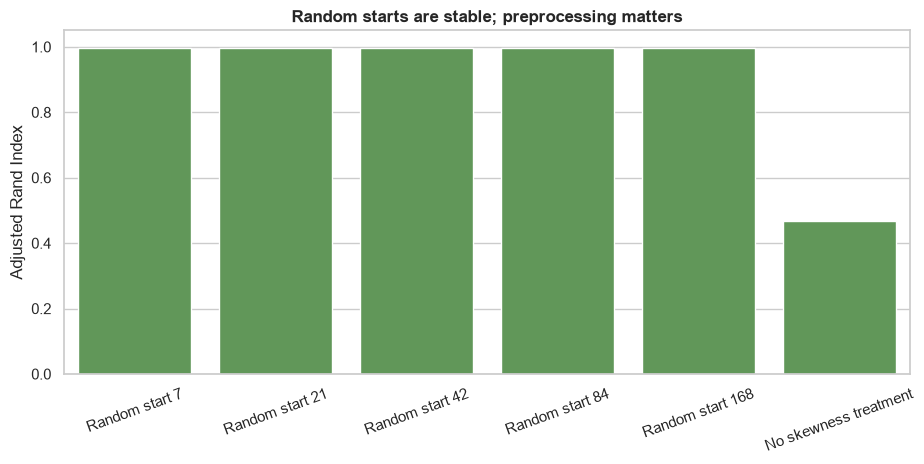

In [17]:
saved_segmentation_preprocessor = joblib.load(PREPROCESSING_MODEL_PATH)
saved_pca = joblib.load(PCA_MODEL_PATH)
saved_clustering_model = joblib.load(CLUSTERING_MODEL_PATH)

segmentation_features = list(saved_segmentation_preprocessor.feature_names_in_)
segmentation_matrix = saved_segmentation_preprocessor.transform(
    customer_features[segmentation_features]
)
saved_segment_labels = saved_clustering_model.predict(segmentation_matrix)

stability_rows = []
for seed in [7, 21, 42, 84, 168]:
    repeated_model = KMeans(
        n_clusters=saved_clustering_model.n_clusters,
        n_init=20,
        random_state=seed,
    )
    repeated_labels = repeated_model.fit_predict(segmentation_matrix)
    stability_rows.append(
        {
            "test": f"Random start {seed}",
            "adjusted_rand_index": adjusted_rand_score(saved_segment_labels, repeated_labels),
            "smallest_segment": int(pd.Series(repeated_labels).value_counts().min()),
        }
    )

standard_only_matrix = StandardScaler().fit_transform(
    customer_features[segmentation_features]
)
standard_only_labels = KMeans(
    n_clusters=saved_clustering_model.n_clusters,
    n_init=50,
    random_state=RANDOM_STATE,
).fit_predict(standard_only_matrix)
stability_rows.append(
    {
        "test": "No skewness treatment",
        "adjusted_rand_index": adjusted_rand_score(saved_segment_labels, standard_only_labels),
        "smallest_segment": int(pd.Series(standard_only_labels).value_counts().min()),
    }
)

cluster_stability = pd.DataFrame(stability_rows)
display(cluster_stability.round(3))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
sns.barplot(data=cluster_stability, x="test", y="adjusted_rand_index", color="#59A14F", ax=ax)
ax.set(
    title="Random starts are stable; preprocessing matters",
    xlabel="",
    ylabel="Adjusted Rand Index",
    ylim=(0, 1.05),
)
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cluster_stability_check.png", dpi=160, bbox_inches="tight")
plt.show()


### Explanations used across the project

Different analyses need different explanations:

| Analysis | Explanation used | What it tells us |
|---|---|---|
| Customer segments | Original-scale segment profiles | Typical behavior and service use in each segment |
| PCA | PCA loadings | Which input features contribute most to each component |
| Behavioral outliers | Largest within-segment feature difference | Why an account looks unusual compared with its segment |
| Logistic regression | Model coefficients | Which inputs move the fitted model score up or down |

None of these explanations proves cause.


In [18]:
segment_explanation = segment_profiles[
    [
        "segment_name",
        "population_size",
        "population_share",
        "defining_features",
        "transaction_patterns",
        "balance_characteristics",
        "banking_service_usage",
        "possible_business_relevance",
        "limitations",
    ]
].copy()
display(segment_explanation)


,segment_name,population_size,population_share,defining_features,transaction_patterns,balance_characteristics,banking_service_usage,possible_business_relevance,limitations
0,Pension-associated households,1305,0.290000,low average inflow (-1.09 SD); low cash-deposi...,"Lower-value recurring inflows, very low cash-d...",Lowest typical balances and comparatively low ...,Nearly universal standing orders and household...,Investigate accessible servicing and reliable ...,The pension flag is historical and not univers...
1,Established household users,1519,0.337556,high average inflow (+0.71 SD); high average b...,Moderate activity with larger inflows and mixe...,High typical balances with moderate volatility.,Household payments and standing orders are com...,Investigate everyday-service experience and ch...,High balance and service use do not establish ...
2,High-activity multi-service users,838,0.186222,high transaction intensity (+1.31 SD); high tr...,Highest transaction intensity and transaction ...,High typical balances with moderate volatility.,"Broadest service use; loans, cards, insurance,...",Investigate service coordination and operation...,High activity is not evidence of customer valu...
3,High-volatility cash users,251,0.055778,high negative-balance exposure (+3.96 SD); hig...,High cash-withdrawal share and relatively high...,Highest balance volatility and the clearest ne...,"Fewer recurring services, although loans and l...",Investigate aggregate cash-flow support and se...,Volatility and negative balances are valid fin...
4,Low-service cash users,587,0.130444,low transaction diversity (-1.39 SD); high cas...,Lower activity and diversity with a high cash-...,Mid-range typical balances and moderate volati...,"Few observed services; loans, salary-like depo...","Investigate voluntary onboarding, education, o...",Low observed service use does not imply low en...


In [19]:
pca_loading_matrix = pd.DataFrame(
    saved_pca.components_[:4].T,
    index=segmentation_features,
    columns=["PC1", "PC2", "PC3", "PC4"],
)

pca_top_features = []
for component in pca_loading_matrix.columns:
    for feature, loading in pca_loading_matrix[component].abs().nlargest(3).items():
        pca_top_features.append(
            {
                "component": component,
                "feature": feature,
                "loading": pca_loading_matrix.loc[feature, component],
            }
        )

pca_explanation = pd.DataFrame(pca_top_features)
display(pca_explanation.round(3))


,component,feature,loading
0,PC1,transaction_diversity,0.496
1,PC1,transactions_per_observed_month,0.491
2,PC1,service_diversity,0.483
3,PC2,average_inflow,0.471
4,PC2,average_balance,0.441
5,PC2,cash_withdrawal_share,0.434
6,PC3,negative_balance_share,0.708
7,PC3,average_balance,-0.386
8,PC3,cash_deposit_share,-0.352
9,PC4,cash_deposit_share,0.597


In [20]:
selected_outlier_cases = (
    behavioral_outliers.loc[behavioral_outliers["is_behavioral_outlier"]]
    .sort_values(
        ["outlier_signal_count", "composite_outlier_percentile"],
        ascending=False,
    )
)

display(
    selected_outlier_cases[
        [
            "account_id",
            "segment_name",
            "outlier_signal_count",
            "top_robust_deviation_feature",
            "top_robust_feature_value",
            "top_robust_feature_segment_median",
            "centroid_distance_percentile_within_segment",
            "gmm_max_membership_probability",
        ]
    ].head(10).round(3)
)


,account_id,segment_name,outlier_signal_count,top_robust_deviation_feature,top_robust_feature_value,top_robust_feature_segment_median,centroid_distance_percentile_within_segment,gmm_max_membership_probability
3161,3324,Pension-associated households,3,cash_deposit_share,0.365,0.008,0.998,0.769
3115,3276,Pension-associated households,2,cash_deposit_share,0.368,0.008,1.000,0.958
661,696,Pension-associated households,2,transaction_diversity,8.000,6.000,0.992,0.763
4332,9227,Pension-associated households,2,cash_deposit_share,0.333,0.008,0.996,0.993
3817,4059,High-volatility cash users,2,inflow_to_outflow_ratio,0.796,1.028,1.000,1.000
1795,1888,High-activity multi-service users,2,negative_balance_share,0.052,0.000,1.000,1.000
4049,5442,High-activity multi-service users,2,negative_balance_share,0.074,0.000,0.999,1.000
2217,2335,High-volatility cash users,2,cash_withdrawal_share,0.401,0.676,0.996,1.000
2751,2892,Low-service cash users,2,cash_withdrawal_share,0.077,0.515,1.000,1.000
689,727,Low-service cash users,2,cash_deposit_share,0.818,0.365,0.998,1.000


### Reproducibility, versioning, and ethical interpretation

- Every required input path and a short SHA-256 file fingerprint are shown near the start of the notebook.
- The Python and library versions are recorded.
- Random steps use the same random state.
- The loan features are created with one visible SQL query and one clear date cutoff.
- The three dashboard tables are written at stated row levels and checked after writing.
- Generated data remain outside Git; notebooks, code, intended report figures, and documentation are versioned.

Ethical limits remain more important than a high score. The Berka data describe a different country, time period, product setting, and banking process. The target records one historical status definition, not a complete account of a person’s ability or willingness to repay. The loan sample is small, the problem class is rare, and the data contain no record of rejected applications. These results must not be used for present-day lending or customer treatment.


## 5. Final synthesis

The project’s central result is a behavioral view of accounts, not a loan model. The table below brings the four notebooks together and keeps each conclusion within what the data can support.


In [21]:
largest_segment = segment_profiles.sort_values("population_size", ascending=False).iloc[0]
selected_model_metrics = model_evaluation.loc[
    model_evaluation["model"] == SELECTED_LOAN_MODEL
].iloc[0]

if association_rules_data.empty:
    top_rule_text = "No rule passed the declared filters."
else:
    top_rule = association_rules_data.sort_values(
        ["lift", "confidence", "support"],
        ascending=False,
    ).iloc[0]
    top_rule_text = (
        f"The strongest retained lift is {top_rule['lift']:.2f} for "
        f"{top_rule['rule']}."
    )

final_findings = pd.DataFrame(
    [
        {
            "area": "EDA and behavior",
            "finding": "Accounts differ in activity, cash flow, balance behavior, channel use, and service use.",
            "use": "These differences formed the inputs to segmentation.",
            "limit": "Observed behavior does not reveal customer intent.",
        },
        {
            "area": "Time series",
            "finding": "Monthly activity contains growth and an annual pattern; Notebook 2's declared comparison selected SARIMA.",
            "use": "Aggregate forecasts may support workload planning.",
            "limit": "Only 72 months and one 12-month test window are available.",
        },
        {
            "area": "Service associations",
            "finding": top_rule_text,
            "use": "Rules can become questions for later testing.",
            "limit": "They are not personalized recommendations and do not show cause.",
        },
        {
            "area": "Customer segments",
            "finding": (
                f"Five segments were selected; the largest is {largest_segment['segment_name']} "
                f"with {int(largest_segment['population_size']):,} accounts."
            ),
            "use": "Profiles summarize different patterns of account use.",
            "limit": "Segment names are summaries, not permanent customer labels.",
        },
        {
            "area": "Behavioral outliers",
            "finding": f"{len(selected_outlier_cases):,} accounts meet the conservative two-signal rule.",
            "use": "Cases can be reviewed to understand unusual behavior.",
            "limit": "An outlier is not evidence of fraud or error.",
        },
        {
            "area": "Loan case study",
            "finding": (
                f"Logistic regression reached F1={selected_model_metrics['f1']:.2f} and "
                f"PR-AUC={selected_model_metrics['pr_auc']:.2f} on the fixed test split."
            ),
            "use": "It demonstrates supervised learning and careful feature cutoffs.",
            "limit": "The test set is small and contains few problem loans.",
        },
    ]
)
display(final_findings)


,area,finding,use,limit
0,EDA and behavior,"Accounts differ in activity, cash flow, balanc...",These differences formed the inputs to segment...,Observed behavior does not reveal customer int...
1,Time series,Monthly activity contains growth and an annual...,Aggregate forecasts may support workload plann...,Only 72 months and one 12-month test window ar...
2,Service associations,The strongest retained lift is 3.60 for pays_h...,Rules can become questions for later testing.,They are not personalized recommendations and ...
3,Customer segments,Five segments were selected; the largest is Es...,Profiles summarize different patterns of accou...,"Segment names are summaries, not permanent cus..."
4,Behavioral outliers,16 accounts meet the conservative two-signal r...,Cases can be reviewed to understand unusual be...,An outlier is not evidence of fraud or error.
5,Loan case study,Logistic regression reached F1=0.55 and PR-AUC...,It demonstrates supervised learning and carefu...,The test set is small and contains few problem...


## 6. Dashboard-ready outputs

| Output | Row level | Purpose |
|---|---|---|
| `dashboard_summary.parquet` | One row per headline measure | Project overview cards and short notes |
| `dashboard_segments.parquet` | One row per segment | Segment sizes, profiles, meanings, and outlier counts |
| `dashboard_outliers.parquet` | One row per selected behavioral outlier | Transparent account case-study table |

The dashboard tables contain no model recommendation and no raw client identity fields.


In [22]:
dashboard_summary = pd.DataFrame(
    [
        ("Portfolio", "Accounts", len(customer_features), f"{len(customer_features):,}", "Account-level coverage"),
        ("Portfolio", "Transactions", int(monthly_activity["transaction_count"].sum()), f"{int(monthly_activity['transaction_count'].sum()):,}", "Clean transaction records"),
        ("Time", "Observed months", len(monthly_activity), f"{len(monthly_activity)}", "Monthly aggregate history"),
        ("Services", "Retained association rules", len(association_rules_data), f"{len(association_rules_data)}", "Hypotheses, not recommendations"),
        ("Segmentation", "Segments", len(segment_profiles), f"{len(segment_profiles)}", "Selected K-means solution"),
        ("Segmentation", "Behavioral outliers", len(selected_outlier_cases), f"{len(selected_outlier_cases)}", "Accounts meeting at least two signals"),
        ("Loan case study", "Completed loans", len(loan_model_data), f"{len(loan_model_data)}", "Only loans with known final status"),
        ("Loan case study", "Recorded problem loans", int(y.sum()), f"{int(y.sum())}", "Uncommon target class"),
        ("Loan case study", "Logistic-regression F1", float(selected_model_metrics["f1"]), f"{selected_model_metrics['f1']:.2f}", "Fixed historical test split"),
        ("Loan case study", "Logistic-regression PR-AUC", float(selected_model_metrics["pr_auc"]), f"{selected_model_metrics['pr_auc']:.2f}", "Useful with an uncommon target"),
    ],
    columns=["section", "metric", "numeric_value", "display_value", "note"],
)

outlier_counts_by_segment = (
    behavioral_outliers.groupby(["segment_id", "segment_name"])
    .agg(
        behavioral_outlier_count=("is_behavioral_outlier", "sum"),
        account_count=("account_id", "size"),
    )
    .reset_index()
)
outlier_counts_by_segment["behavioral_outlier_rate"] = (
    outlier_counts_by_segment["behavioral_outlier_count"]
    / outlier_counts_by_segment["account_count"]
)

dashboard_segments = segment_profiles.merge(
    outlier_counts_by_segment[
        [
            "segment_id",
            "behavioral_outlier_count",
            "behavioral_outlier_rate",
        ]
    ],
    on="segment_id",
    how="left",
)

dashboard_outliers = selected_outlier_cases.merge(
    customer_features[
        [
            "account_id",
            "transactions_per_observed_month",
            "average_inflow",
            "average_outflow",
            "average_balance",
            "negative_balance_share",
            "transaction_diversity",
            "service_diversity",
            "has_card",
            "has_loan",
            "has_standing_order",
        ]
    ],
    on="account_id",
    how="left",
).sort_values(
    ["outlier_signal_count", "composite_outlier_percentile"],
    ascending=False,
)

display(dashboard_summary)
display(
    dashboard_segments[
        [
            "segment_name",
            "population_size",
            "population_share",
            "behavioral_outlier_count",
            "behavioral_outlier_rate",
        ]
    ].round(3)
)
display(dashboard_outliers.head())


,section,metric,numeric_value,display_value,note
0,Portfolio,Accounts,4.500000e+03,"4,500",Account-level coverage
1,Portfolio,Transactions,1.056320e+06,"1,056,320",Clean transaction records
2,Time,Observed months,7.200000e+01,72,Monthly aggregate history
3,Services,Retained association rules,5.000000e+00,5,"Hypotheses, not recommendations"
4,Segmentation,Segments,5.000000e+00,5,Selected K-means solution
5,Segmentation,Behavioral outliers,1.600000e+01,16,Accounts meeting at least two signals
6,Loan case study,Completed loans,2.340000e+02,234,Only loans with known final status
7,Loan case study,Recorded problem loans,3.100000e+01,31,Uncommon target class
8,Loan case study,Logistic-regression F1,5.454545e-01,0.55,Fixed historical test split
9,Loan case study,Logistic-regression PR-AUC,4.714790e-01,0.47,Useful with an uncommon target


,segment_name,population_size,population_share,behavioral_outlier_count,behavioral_outlier_rate
0,Pension-associated households,1305,0.290,5,0.004
1,Established household users,1519,0.338,0,0.000
2,High-activity multi-service users,838,0.186,2,0.002
3,High-volatility cash users,251,0.056,3,0.012
4,Low-service cash users,587,0.130,6,0.010


,account_id,segment_id,segment_name,centroid_distance,centroid_distance_percentile_within_segment,gmm_max_membership_probability,robust_deviation_score,top_robust_deviation_feature,isolation_anomaly_score,centroid_distance_flag,...,transactions_per_observed_month,average_inflow,average_outflow,average_balance,negative_balance_share,transaction_diversity,service_diversity,has_card,has_loan,has_standing_order
0,3324,0,Pension-associated households,3.443532,0.997701,0.769421,42.656022,cash_deposit_share,0.513180,True,...,5.133333,3875.621622,2153.975000,42848.805195,0.000000,7,3,True,False,True
1,3276,0,Pension-associated households,3.942576,1.000000,0.958282,42.980232,cash_deposit_share,0.540224,True,...,5.307692,3202.303030,1748.583333,32718.362319,0.000000,7,3,False,False,True
2,696,0,Pension-associated households,3.137413,0.991571,0.762624,3.689158,transaction_diversity,0.562409,True,...,4.428571,3689.280000,976.513514,40343.548387,0.000000,8,4,True,False,True
3,9227,0,Pension-associated households,3.272815,0.996169,0.993374,39.519855,cash_deposit_share,0.529445,True,...,7.142857,2139.461538,2001.229167,16424.470000,0.000000,7,3,False,True,True
4,4059,3,High-volatility cash users,10.627012,1.000000,1.000000,15.269829,inflow_to_outflow_ratio,0.688144,True,...,1.682540,859.614286,2100.000000,11028.471698,0.179245,3,1,False,False,True


In [23]:
dashboard_outputs = {
    "dashboard_summary.parquet": dashboard_summary,
    "dashboard_segments.parquet": dashboard_segments,
    "dashboard_outliers.parquet": dashboard_outliers,
}

for index, (filename, frame) in enumerate(dashboard_outputs.items()):
    relation_name = f"dashboard_output_{index}"
    output_path = PROCESSED_DIR / filename
    connection.register(relation_name, frame)
    connection.execute(
        "COPY (SELECT * FROM "
        + relation_name
        + ") TO "
        + sql_literal(output_path)
        + " (FORMAT PARQUET, COMPRESSION ZSTD)"
    )
    connection.unregister(relation_name)

output_validation_rows = []
for filename, frame in dashboard_outputs.items():
    output_path = PROCESSED_DIR / filename
    stored_rows = connection.execute(
        "SELECT COUNT(*) FROM read_parquet(" + sql_literal(output_path) + ")"
    ).fetchone()[0]
    output_validation_rows.append(
        {
            "artifact": filename,
            "path": str(output_path.relative_to(PROJECT_ROOT)),
            "expected_rows": len(frame),
            "stored_rows": stored_rows,
            "columns": len(frame.columns),
            "valid": stored_rows == len(frame),
        }
    )

figure_names = [
    "loan_target_distribution.png",
    "loan_model_comparison.png",
    "loan_logistic_confusion_matrix.png",
    "loan_outcomes_by_year.png",
    "cluster_stability_check.png",
]
for filename in figure_names:
    output_path = FIGURES_DIR / filename
    output_validation_rows.append(
        {
            "artifact": filename,
            "path": str(output_path.relative_to(PROJECT_ROOT)),
            "expected_rows": None,
            "stored_rows": None,
            "columns": None,
            "valid": output_path.is_file(),
        }
    )

output_validation = pd.DataFrame(output_validation_rows)
display(output_validation)

assert output_validation["valid"].all()
assert dashboard_summary["metric"].is_unique
assert dashboard_segments["segment_id"].is_unique
assert dashboard_outliers["account_id"].is_unique
assert len(dashboard_outliers) == int(behavioral_outliers["is_behavioral_outlier"].sum())


,artifact,path,expected_rows,stored_rows,columns,valid
0,dashboard_summary.parquet,data/processed/dashboard_summary.parquet,10.0,10.0,5.0,True
1,dashboard_segments.parquet,data/processed/dashboard_segments.parquet,5.0,5.0,32.0,True
2,dashboard_outliers.parquet,data/processed/dashboard_outliers.parquet,16.0,16.0,28.0,True
3,loan_target_distribution.png,reports/figures/loan_target_distribution.png,NaN,NaN,NaN,True
4,loan_model_comparison.png,reports/figures/loan_model_comparison.png,NaN,NaN,NaN,True
5,loan_logistic_confusion_matrix.png,reports/figures/loan_logistic_confusion_matrix...,NaN,NaN,NaN,True
6,loan_outcomes_by_year.png,reports/figures/loan_outcomes_by_year.png,NaN,NaN,NaN,True
7,cluster_stability_check.png,reports/figures/cluster_stability_check.png,NaN,NaN,NaN,True


## 7. Conclusions

- The loan case study uses only completed loans and only information available before each loan began.
- The dummy baseline shows why accuracy alone is misleading when problem loans are rare.
- Logistic regression gives the clearest balance of test results and explanation in this small comparison.
- Earlier account behavior adds information beyond loan terms, while adding region and a rare card flag does not clearly help.
- The test sample is small, contains few problem loans, and does not support production or present-day lending claims.
- Data coverage, historical change, regional sample sizes, missing values, and model errors are documented instead of hidden.
- The five customer segments remain stable across random starts, but they are still descriptive summaries rather than permanent customer types.
- Segment profiles, PCA loadings, outlier feature differences, and logistic coefficients provide explanations suited to each method.
- Three checked Parquet tables now provide a simple handoff for a future dashboard.

The project is ready for final reporting or a lightweight dashboard. Any future dashboard should present these limits beside the results rather than showing scores without context.
